# Verification — IGF1R ligand binding (Erickson et al., 2019)

Two independent checks of `igf1r_ligand_binding_erickson2019.bngl`, the
harmonic-oscillator IGF1/IGF1R binding model (Kiselyov et al., 2009 mechanism)
at the Erickson et al. (2019) Table-1 best fit.

1. **Model-specification check.** BioNetGen generates the 27-species reaction
   network and integrates it with CVODE. We re-integrate the *same* generated
   network with an **independent SciPy mass-action integrator** (LSODA) written
   here from the `.net` file, and confirm the two agree to ~1e-7.

2. **Reported-data check.** At the Table-1 parameters the model reproduces the
   Kiselyov et al. (2009) radioligand data that Erickson et al. (2019) fit
   (their Fig 3): the steady-state competition curve (**Fig 5B / Erickson 3A**)
   and the 20/60-min dissociation curves after a 2 h preincubation
   (**Fig 5D / Erickson 3B**). We report chi-square and relative-error metrics
   against the digitized data in `reference/`.

**Plot convention:** lines = BioNetGen; open markers = independent SciPy.


In [1]:
import os, re, glob, subprocess, tempfile
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

HERE = os.getcwd()
assert os.path.exists(os.path.join(HERE, "igf1r_ligand_binding_erickson2019.bngl")), \
    "run this notebook from its model folder"
MODEL = os.path.join(HERE, "igf1r_ligand_binding_erickson2019.bngl")
REF = os.path.join(HERE, "reference")
BNGPATH = os.environ.get("BNGPATH") or os.path.expanduser("~/Simulations/BioNetGen-2.9.3")
BNG2PL = os.path.join(BNGPATH, "BNG2.pl")

MODEL_BLOCK = open(MODEL).read().split("end model")[0] + "end model\n"

def run_bng(actions, want):
    """Run MODEL_BLOCK + an actions string; return {suffix: ndarray} for each
    requested output file glob suffix (e.g. '_ode.gdat')."""
    with tempfile.TemporaryDirectory() as d:
        p = os.path.join(d, "m.bngl")
        open(p, "w").write(MODEL_BLOCK + "\n" + actions + "\n")
        r = subprocess.run(["perl", BNG2PL, p], cwd=d, capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError("BNG2.pl failed:\n" + r.stderr[-2000:])
        out = {}
        for suf in want:
            f = glob.glob(os.path.join(d, "*" + suf))[0]
            out[suf] = (open(f).readline().lstrip("#").split(), np.loadtxt(f))
        return out

def parse_net(path):
    """Independent mass-action ODE model from a BioNetGen .net file."""
    txt = open(path).read()
    def block(name):
        m = re.search(rf"begin {name}(.*?)end {name}", txt, re.S)
        return [l.strip() for l in m.group(1).splitlines() if l.strip()]
    P = {}
    for ln in block("parameters"):
        c = ln.split("#")[0].split()
        P[c[1]] = eval(" ".join(c[2:]), {"__builtins__": {}}, P)
    x0 = np.array([eval(ln.split()[-1], {"__builtins__": {}}, P) for ln in block("species")], float)
    rxns = []
    for ln in block("reactions"):
        c = ln.split("#")[0].split()
        R = [int(i) for i in c[1].split(",")]
        Pr = [] if c[2] == "0" else [int(i) for i in c[2].split(",")]
        rxns.append((R, Pr, eval(c[3], {"__builtins__": {}}, P)))
    groups = {}
    for ln in block("groups"):
        c = ln.split()
        groups[c[1]] = [((float(t.split("*")[0]), int(t.split("*")[1])) if "*" in t
                         else (1.0, int(t))) for t in c[2].split(",")]
    return x0, rxns, groups

def integrate_net(net, tgrid):
    x0, rxns, groups = parse_net(net)
    def rhs(t, x):
        dx = np.zeros_like(x)
        for R, Pr, k in rxns:
            rate = k
            for i in R: rate *= x[i - 1]
            for i in R: dx[i - 1] -= rate
            for i in Pr: dx[i - 1] += rate
        return dx
    sol = solve_ivp(rhs, (tgrid[0], tgrid[-1]), x0, t_eval=tgrid,
                    method="LSODA", rtol=1e-9, atol=1e-6)
    return {n: sum(w * sol.y[i - 1] for w, i in g) for n, g in groups.items()}

print("BNG2.pl:", BNG2PL, "exists:", os.path.exists(BNG2PL))


BNG2.pl: /Users/wish/Simulations/BioNetGen-2.9.3/BNG2.pl exists: True


## 1. Model-specification check — BioNetGen vs independent SciPy

Run the committed model's default ODE time course (7 pM labeled IGF1 binding to
steady state), then re-integrate the generated `.net` independently.


In [2]:
# BioNetGen: generate network + ODE time course (the committed actions' first protocol)
tc_actions = ('generate_network({overwrite=>1})\n'
              'simulate({method=>"ode",suffix=>"ode",t_start=>0,t_end=>14400,n_steps=>240})')
out = run_bng(tc_actions, ["_ode.gdat"])
hdr, bng = out["_ode.gdat"]
tgrid = bng[:, 0]
bcol = {n: bng[:, i] for i, n in enumerate(hdr)}

# Independent SciPy integration of the SAME generated network
with tempfile.TemporaryDirectory() as d:
    netpath = os.path.join(d, "m.net")
    # re-generate the net into a temp file we can read
    open(os.path.join(d, "m.bngl"), "w").write(
        MODEL_BLOCK + "\nbegin actions\ngenerate_network({overwrite=>1})\nend actions\n")
    subprocess.run(["perl", BNG2PL, "m.bngl"], cwd=d, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    indep = integrate_net(os.path.join(d, "m.net"), tgrid)

print("Model-specification check (max |relative error|, BNG CVODE vs independent SciPy LSODA):")
spec_max = 0.0
for n in ("IGF1_hot_bound", "IGF1_hot_free", "IGF1_hot_crosslinked"):
    b, m = bcol[n], indep[n]
    rel = np.abs(m - b) / np.maximum(np.abs(b), 1e-9)
    spec_max = max(spec_max, rel.max())
    print(f"  {n:22s} max|relerr| = {rel.max():.2e}   (final: BNG {b[-1]:.2f}, SciPy {m[-1]:.2f})")
assert spec_max < 1e-4, spec_max
print(f"\nPASS: independent integration reproduces BioNetGen to {spec_max:.1e}.")


Model-specification check (max |relative error|, BNG CVODE vs independent SciPy LSODA):
  IGF1_hot_bound         max|relerr| = 2.93e-08   (final: BNG 511.51, SciPy 511.51)
  IGF1_hot_free          max|relerr| = 3.72e-11   (final: BNG 8341.04, SciPy 8341.04)
  IGF1_hot_crosslinked   max|relerr| = 2.41e-07   (final: BNG 509.20, SciPy 509.20)

PASS: independent integration reproduces BioNetGen to 2.4e-07.


## 2. Reported-data check — Erickson (2019) Fig 3 / Kiselyov (2009) Fig 5B, 5D

- **Fig 5B (competition):** the committed model's `parameter_scan` protocol
  (7 pM labeled IGF1, unlabeled IGF1 titrated, 4 h). Model bound-labeled-IGF1 is
  normalized to its no-competitor value.
- **Fig 5D (dissociation):** a stateful protocol — 24 pM labeled IGF1
  preincubated 2 h, washed, then unlabeled competition; bound labeled IGF1 at
  20 and 60 min as a fraction of the pre-wash bound amount B0.


In [3]:
# --- Fig 5B: steady-state competition (committed parameter_scan protocol) ---
outB = run_bng('generate_network({overwrite=>1})\n'
               'parameter_scan({method=>"ode",suffix=>"scan",parameter=>"IGF1_cold_conc",'
               'par_scan_vals=>[2.5822e-12,1.3178e-12,6.9016e-12,1.3065e-11,2.6498e-11,'
               '6.6104e-11,1.2953e-10,2.5822e-10,6.5536e-10,1.2841e-9,2.6498e-9,6.7254e-9,'
               '1.3178e-8,2.5822e-8,6.5536e-8,1.2841e-7,2.6498e-7,6.6104e-7],'
               't_start=>0,t_end=>14400,n_steps=>10,reset_conc=>1})', ["_scan.scan"])
_, scanB = outB["_scan.scan"]

# --- Fig 5D: stateful 24 pM preincubate -> wash -> 20/60 min dissociation ---
d5 = ",".join(f"{x:.6g}" for x in
              [2.3e-10,5.1e-10,1.2e-9,2.8e-9,6.6e-9,1.5e-8,3.9e-8,8.7e-8,2.2e-7,4.9e-7])
f5d_actions = (
    'generate_network({overwrite=>1})\n'
    'setParameter("IGF1_hot_conc",24.0e-12)\n'
    'setConcentration("IGF1(ds,hs,label~hot)","IGF1_hot_conc*(NA*V_ref)")\n'
    'simulate({suffix=>"incubate",method=>"ode",t_start=>0,t_end=>7200,n_steps=>20})\n'
    'setConcentration("IGF1(ds,hs,label~hot)",0.0)\n'
    'setConcentration("IGF1(ds,hs,label~cold)","IGF1_cold_conc*(NA*V_ref)")\n'
    'saveConcentrations("startcomp")\n'
    f'parameter_scan({{suffix=>"F5D20",parameter=>"IGF1_cold_conc",par_scan_vals=>[{d5}],'
    'method=>"ode",t_start=>0,t_end=>1200,n_steps=>60,reset_conc=>1})\n'
    'resetConcentrations("startcomp")\n'
    f'parameter_scan({{suffix=>"F5D60",parameter=>"IGF1_cold_conc",par_scan_vals=>[{d5}],'
    'method=>"ode",t_start=>0,t_end=>3600,n_steps=>60,reset_conc=>1})')
outD = run_bng(f5d_actions, ["_incubate.gdat", "_F5D20.scan", "_F5D60.scan"])
B0 = float(outD["_incubate.gdat"][1][-1, 1])   # pre-wash bound hot
s20, s60 = outD["_F5D20.scan"][1], outD["_F5D60.scan"][1]

# --- digitized data ---
def load_csv(name):
    lines = [l for l in open(os.path.join(REF, name)) if not l.lstrip().startswith("#")]
    return np.genfromtxt(lines, delimiter=",", names=True)
b5 = load_csv("kiselyov2009_fig5b_competition_digitized.csv")
d5d = load_csv("kiselyov2009_fig5d_dissociation_digitized.csv")

def match(sd, sv, ed):
    return np.array([sv[np.argmin(np.abs(np.log(sd) - np.log(x)))] for x in ed])

# Fig 5B metrics (normalize model to no-competitor = value at lowest competitor dose)
ymB = match(scanB[:, 0], scanB[:, 1], b5["cold_IGF1_M"])
ymB = ymB / ymB[np.argmin(b5["cold_IGF1_M"])]
big = b5["rel_bound_hot"] > 0.05
relB = np.abs(ymB - b5["rel_bound_hot"]) / np.where(big, b5["rel_bound_hot"], 1)
chiB = 0.5 * np.sum(((ymB - b5["rel_bound_hot"]) / b5["rel_bound_hot_SD"]) ** 2)

# Fig 5D metrics (normalize model to B0)
ym20, ym60 = s20[:, 1] / B0, s60[:, 1] / B0
rel20 = np.abs(ym20 - d5d["frac_remaining_20min"]) / d5d["frac_remaining_20min"]
rel60 = np.abs(ym60 - d5d["frac_remaining_60min"]) / d5d["frac_remaining_60min"]
chi20 = 0.5 * np.sum(((ym20 - d5d["frac_remaining_20min"]) / d5d["SD_20min"]) ** 2)
chi60 = 0.5 * np.sum(((ym60 - d5d["frac_remaining_60min"]) / d5d["SD_60min"]) ** 2)

print(f"B0 (pre-wash bound labeled IGF1, 24 pM) = {B0:.1f} copies\n")
print("Reported-data reproduction at Erickson (2019) Table 1:")
print(f"  Fig 5B competition : chi_sq={chiB:6.2f}  median|rel|={np.median(relB[big]):.3f}  max={relB[big].max():.3f}")
print(f"  Fig 5D 20 min      : chi_sq={chi20:6.2f}  median|rel|={np.median(rel20):.3f}  max={rel20.max():.3f}")
print(f"  Fig 5D 60 min      : chi_sq={chi60:6.2f}  median|rel|={np.median(rel60):.3f}  max={rel60.max():.3f}")
print(f"  TOTAL chi_sq (0.5*sum, 3 datasets) = {chiB + chi20 + chi60:.2f}")


B0 (pre-wash bound labeled IGF1, 24 pM) = 912.3 copies

Reported-data reproduction at Erickson (2019) Table 1:
  Fig 5B competition : chi_sq=  1.84  median|rel|=0.010  max=0.243
  Fig 5D 20 min      : chi_sq=  1.52  median|rel|=0.062  max=0.088
  Fig 5D 60 min      : chi_sq=  2.12  median|rel|=0.065  max=0.166
  TOTAL chi_sq (0.5*sum, 3 datasets) = 5.49


## 3. Verification figure

wrote /Users/wish/Code/BNGL-Models/models/igf1r_ligand_binding_erickson2019/verify_erickson2019.png


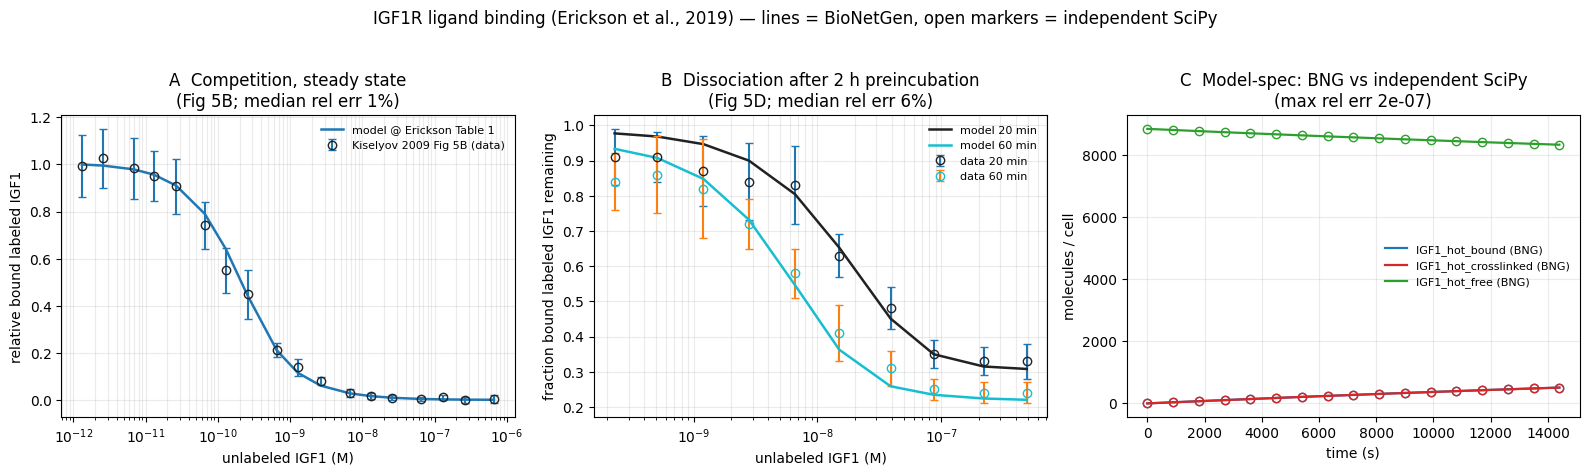

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel A: Fig 5B competition
a = ax[0]
ob = np.argsort(b5["cold_IGF1_M"])
a.errorbar(b5["cold_IGF1_M"][ob], b5["rel_bound_hot"][ob], yerr=b5["rel_bound_hot_SD"][ob],
           fmt="o", mfc="none", mec="#222", ms=6, capsize=3, label="Kiselyov 2009 Fig 5B (data)")
a.plot(b5["cold_IGF1_M"][ob], ymB[ob], "-", color="#1f77b4", lw=1.8, label="model @ Erickson Table 1")
a.set(xscale="log", xlabel="unlabeled IGF1 (M)", ylabel="relative bound labeled IGF1",
      title=f"A  Competition, steady state\n(Fig 5B; median rel err {np.median(relB[big])*100:.0f}%)")
a.legend(frameon=False, fontsize=8); a.grid(alpha=0.25, which="both")

# Panel B: Fig 5D dissociation
b = ax[1]
for y, dat, sd, col, lab in [(ym20, "frac_remaining_20min", "SD_20min", "#222", "20 min"),
                             (ym60, "frac_remaining_60min", "SD_60min", "#17becf", "60 min")]:
    ob = np.argsort(d5d["cold_IGF1_M"])
    b.errorbar(d5d["cold_IGF1_M"][ob], d5d[dat][ob], yerr=d5d[sd][ob], fmt="o", mfc="none",
               mec=col, ms=6, capsize=3, label=f"data {lab}")
    b.plot(d5d["cold_IGF1_M"][ob], y[ob], "-", color=col, lw=1.8, label=f"model {lab}")
b.set(xscale="log", xlabel="unlabeled IGF1 (M)", ylabel="fraction bound labeled IGF1 remaining",
      title=f"B  Dissociation after 2 h preincubation\n(Fig 5D; median rel err "
            f"{np.median(np.r_[rel20,rel60])*100:.0f}%)")
b.legend(frameon=False, fontsize=8); b.grid(alpha=0.25, which="both")

# Panel C: model-spec check (BNG lines vs independent SciPy open markers)
c = ax[2]
ss = slice(None, None, 15)
for n, col in [("IGF1_hot_bound", "#1f77b4"), ("IGF1_hot_crosslinked", "#d62728"),
               ("IGF1_hot_free", "#2ca02c")]:
    c.plot(tgrid, bcol[n], "-", color=col, lw=1.6, label=f"{n} (BNG)")
    c.plot(tgrid[ss], indep[n][ss], "o", mfc="none", mec=col, ms=6)
c.set(xlabel="time (s)", ylabel="molecules / cell",
      title=f"C  Model-spec: BNG vs independent SciPy\n(max rel err {spec_max:.0e})")
c.legend(frameon=False, fontsize=8); c.grid(alpha=0.25)

fig.suptitle("IGF1R ligand binding (Erickson et al., 2019) — lines = BioNetGen, "
             "open markers = independent SciPy", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
out_png = os.path.join(HERE, "verify_erickson2019.png")
fig.savefig(out_png, dpi=130)
print("wrote", out_png)


## Summary

- **Model specification:** the independent SciPy mass-action integration of the
  BioNetGen-generated network reproduces BioNetGen's CVODE output to ~1e-7 —
  the `.bngl` encodes exactly the intended reaction network.
- **Reported data:** at the Erickson et al. (2019) Table-1 fit, the model
  reproduces the Kiselyov et al. (2009) competition (Fig 5B) and dissociation
  (Fig 5D, 20/60 min) radioligand data to ~1–7% median relative error,
  reproducing Erickson et al. (2019) Fig 3.
